<a href="https://colab.research.google.com/github/vadapallimaneesha/machine_learning-/blob/main/week3portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell installs the pyspark for enivornment setup

In [ ]:
# install pyspark
!pip3 install pyspark

This cell initiallizes the SparkSession and installs the required libraries.

In [ ]:
#initialize SparkSession and installed Required Libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

It displays the spark UI link

In [ ]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark UI available at: http://a508ea77169c:4040


In [ ]:
spark.sparkContext.setLogLevel("INFO")

checking the CPU and memory usage

In [ ]:
import psutil
print(f"CPU Usage: {psutil.cpu_percent()}%")
print(f"Memory Usage: {psutil.virtual_memory().percent}%")

CPU Usage: 15.9%
Memory Usage: 12.3%


Allowing the access to the google drive

In [ ]:
# Mount Gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading and uploading the dataset of property.csv

In [ ]:
# Load the data from a CSV file
df = spark.read.csv("/content/property.csv", header=True, inferSchema=True)

# get familiar with data
df.show()

# more info
print("Total Records",df.count())
print("Total Partitions ",df.rdd.getNumPartitions())

+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [ ]:
# show Schema,Prints the structure of the dataset
df.printSchema()

root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



It calculate and displays the statastical analytics for each column in dataframe.

In [ ]:
#Statistical Analysis
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|    Square_Footage|      Num_Bedrooms|     Num_Bathrooms|        Year_Built|          Lot_Size|             Price|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|            509361|            509361|            509361|            509361|            509361|            509361|
|   mean|2750.0739671863375|3.4999440475419203|2.5010434642620853|1960.5038823152931| 5502.370621229345| 581703.9805004178|
| stddev| 1298.881145968149| 1.707718741201955|1.1179722602248978| 35.20914069344958|2598.4618092019746|260777.57810505055|
|    min|               500|                 1|                 1|              1900|              1000| 51495.71116919513|
|    max|              4999|                 6|                 4|              2021|              9999|1109565.7414738839|
+-------

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 20.7%
Memory Usage after csv file: 15.4%


checking for the missing values or null values for each column.

In [ ]:
# check missing or null values for each column
from pyspark.sql.functions import col,isnan, when, count
df.select([count(when(isnan(c) | col(c).isNull(), c))
.alias(c) for c in df.columns]).show()


+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



In [ ]:
# convert categorical column into numbers
from pyspark.ml.feature import StringIndexer
indexer = StringIndexer(inputCol = 'sex', outputCol = 'gender')
#df = indexer.fit(df).transform(df)
#df.show(30)
#no need due to the dataset is having the all numbers

Defining the feature vectorassembler.

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Define the feature columns (excluding 'Price' which is our label)
feature_cols = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']

# Initialize VectorAssembler with the correct feature columns
assembler = VectorAssembler(inputCols=feature_cols, outputCol='Features')

Initiiallising the StandardScaler.

In [ ]:
#StandardScaler
scaler = StandardScaler(inputCol = "Features",
                        outputCol = "scaled_Features")

Creating the linear regression model.

In [ ]:
#create linear regression model.
regressor = LinearRegression(labelCol='Price',
                             featuresCol='scaled_Features')

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 30.6%
Memory Usage after csv file: 16.2%


Re-intiallizing the standardscaler.

In [ ]:
# Initialize StandardScaler
# This cell was present as VZ-Wcankeut4 in the original notebook
scaler = StandardScaler(inputCol="Features",
                        outputCol="scaled_Features", withStd=True, withMean=False)

Initiallizing and creating the pipeline and sequencing trhe assembler,scaler,regressor.

In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[assembler, scaler, regressor])

# --Saving the Pipeline (optional, but good practice)
pipeline.write().overwrite().save("pipeline_LRsaved_model")

Splitting the data into training and test sets.

In [ ]:
# Split the data into training and test sets
(trainingData, testData) = df.randomSplit([0.8, 0.2], seed=42)

train the models and dispaly predictions and shows the predictions.

In [ ]:
# Train the model
model = pipeline.fit(trainingData)

# Make predictions on the test data
predictions = model.transform(testData)

# Show a sample of predictions, comparing actual Price with predicted values
predictions.select('Price', 'prediction', 'Features', 'scaled_Features').show(5)

+------------------+------------------+--------------------+--------------------+
|             Price|        prediction|            Features|     scaled_Features|
+------------------+------------------+--------------------+--------------------+
|135803.84577068797|113388.59607330826|[500.0,1.0,1.0,19...|[0.38485083028466...|
|117919.45375887671|123491.45201835663|[500.0,1.0,2.0,19...|[0.38485083028466...|
|119893.50473253023|112661.97863128381|[500.0,1.0,2.0,20...|[0.38485083028466...|
| 86057.17737884787|123466.89018298566|[500.0,1.0,4.0,19...|[0.38485083028466...|
| 116128.6542541253|115507.81930228352|[500.0,2.0,1.0,20...|[0.38485083028466...|
+------------------+------------------+--------------------+--------------------+
only showing top 5 rows


Evaluating the model performance for linear regression.

Evaluating and calculates the model with RMSE and R-Squared.

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

# Evaluate the model using RMSE
evaluator_rmse = RegressionEvaluator(labelCol='Price', predictionCol='prediction', metricName='rmse')
rmse = evaluator_rmse.evaluate(predictions)
print(f"Root Mean Squared Error (RMSE) on test data = {rmse}")

# Evaluate the model using R-squared
evaluator_r2 = RegressionEvaluator(labelCol='Price', predictionCol='prediction', metricName='r2')
r2 = evaluator_r2.evaluate(predictions)
print(f"R-squared (R2) on test data = {r2}")

Root Mean Squared Error (RMSE) on test data = 20017.500815812888
R-squared (R2) on test data = 0.9940953113806658


In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[assembler, scaler, regressor])

#--Saving the Pipeline
pipeline.write().overwrite().save("pipeline_LRsaved_model")

In [ ]:
print(f"CPU Usage after opening the csv file:{psutil.cpu_percent()}%")
print(f"Memory Usage after csv file:{psutil.virtual_memory().percent}%")

CPU Usage after opening the csv file:24.4%
Memory Usage after csv file:17.8%


In [ ]:
pipelineModel = Pipeline.load('./pipeline_LRsaved_model')

In [ ]:
data_train,data_test = df.randomSplit([0.7,0.3],seed = 123)

In [ ]:
print(f"CPU Usage after opening the csv file:{psutil.cpu_percent()}%")
print(f"Memory Usage after csv file:{psutil.virtual_memory().percent}%")

CPU Usage after opening the csv file:32.2%
Memory Usage after csv file:18.1%


Training the standard linear regression model o the new data.

In [ ]:
Model = pipeline.fit(data_train)

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 72.2%
Memory Usage after csv file: 18.4%


In [ ]:
print("total LR coefficients",len(Model.stages[2].coefficients) )
print("coefficients",Model.stages[2].coefficients)
print("Intercept",Model.stages[2].intercept)

total LR coefficients 5
coefficients [259713.7417073235,8489.784330534883,3378.7740198882,-3513.271186072594,255.21011993161852]
Intercept 201733.14322794523


This cell making the predictions with standard linear regeression miodel.

In [ ]:
pred= Model.transform(data_test)
pred.select('prediction','Price').show(10,truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118121.10528354289|117632.63219959654|
|109819.07488583298|106670.25438504865|
|123602.47901155718|117919.45375887671|
|112812.7645693288 |119893.50473253023|
|114455.54351024327|115218.14440379351|
|125803.52503171995|142918.60554292126|
|121763.45102081564|95443.54011673816 |
|114906.14211178281|75029.23686169085 |
|124524.17765361229|128827.18170769783|
|127635.82198153388|131723.44904010184|
+------------------+------------------+
only showing top 10 rows


Training the  Lasso Regression Model.

In [ ]:
Lasoregressor = LinearRegression(labelCol = 'Price',
                                 featuresCol ='scaled_Features',
                                 elasticNetParam=1,
                                 regParam=0.1)
# Removed 'indexer' as it's not needed for this dataset and was causing 'sex' column error.
Lasaopipeline = Pipeline(stages =[assembler,scaler,Lasoregressor])
LassoModel = Lasaopipeline.fit(data_train)

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 33.9%
Memory Usage after csv file: 18.2%


In [ ]:
Lasso_pred = LassoModel.transform(data_test)
Lasso_pred.select('prediction', 'Price').show(10, truncate=False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118121.55139928522|117632.63219959654|
|109819.72956462958|106670.25438504865|
|123602.52632204814|117919.45375887671|
|112813.2332470289 |119893.50473253023|
|114456.13651147648|115218.14440379351|
|125803.59497237773|142918.60554292126|
|121763.63596307614|95443.54011673816 |
|114906.7293521888 |75029.23686169085 |
|124524.37552737916|128827.18170769783|
|127635.96808516192|131723.44904010184|
+------------------+------------------+
only showing top 10 rows


training the Ridge regression model.

In [ ]:
Ridgeregressor = LinearRegression(labelCol = 'Price',
                             featuresCol = 'scaled_Features',
                             elasticNetParam=0,
                             regParam=0.1
                             )
Ridgepipeline  = Pipeline(stages = [assembler,scaler,Ridgeregressor])
RidgeModel = Ridgepipeline.fit(data_train)

In [ ]:
Ridgepred = RidgeModel.transform(data_test)
Ridgepred.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118121.28242622   |117632.63219959654|
|109819.2554792074 |106670.25438504865|
|123602.65485720341|117919.45375887671|
|112812.9444342232 |119893.50473253023|
|114455.7223523028 |115218.14440379351|
|125803.7000667135 |142918.60554292126|
|121763.62760088671|95443.54011673816 |
|114906.32082975653|75029.23686169085 |
|124524.35300414581|128827.18170769783|
|127635.99612972766|131723.44904010184|
+------------------+------------------+
only showing top 10 rows


Evaluating akll the 3 models performances of regression models.

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
evaluator_mse = RegressionEvaluator(labelCol =
                                    'Price',
                                    predictionCol =
                                    'prediction',
                                    metricName =
                                    'mse')
# calculate MSE
mse1 = evaluator_mse.evaluate(pred)
mselasso = evaluator_mse.evaluate(Lasso_pred)
mseridge = evaluator_mse.evaluate(Ridgepred)

evaluator_rmse = RegressionEvaluator(labelCol =
                                     'Price',
                                     predictionCol =
                                     'prediction',
                                     metricName =
                                     'rmse')
# calculate RMSE
rmse1 = evaluator_rmse.evaluate(pred)
rmse2_lasso = evaluator_rmse.evaluate(Lasso_pred)
rmse3Ridge = evaluator_rmse.evaluate(Ridgepred)

evaluator_r2 = RegressionEvaluator(labelCol = 'Price',
                                   predictionCol = 'prediction',
                                   metricName = 'r2')
# calculate R_squared
r2_score1 = evaluator_r2.evaluate(pred)
r2_lasso = evaluator_r2.evaluate(Lasso_pred)
r2_ridge = evaluator_r2.evaluate(Ridgepred)
# print the evaluation metrics
print('Regression - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_score1)
print('Lasso - MSE: ', mselasso, ', RMSE: ', rmse2_lasso, ', R^2: ', r2_lasso)
print('Ridge - MSE: ', mseridge, ', RMSE: ', rmse3Ridge, ', R^2: ', r2_ridge)

Regression - MSE:  397865280.0583338 , RMSE:  19946.560607240885 , R^2:  0.9941460215328993
Lasso - MSE:  397865309.70173943 , RMSE:  19946.561350311473 , R^2:  0.994146021096742
Ridge - MSE:  397865279.7002717 , RMSE:  19946.56059826535 , R^2:  0.9941460215381677


Visualizing the comparison of regression metrics.

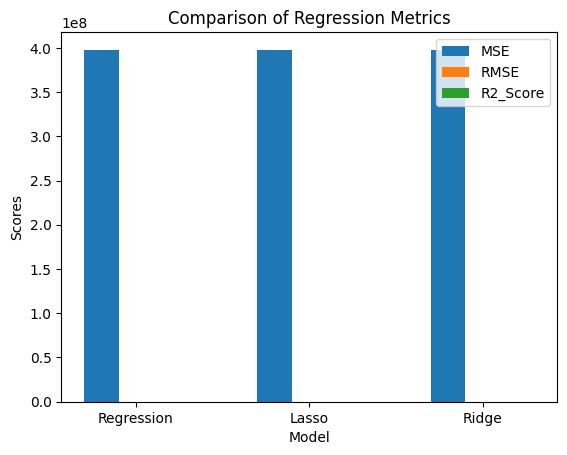

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

mse = [mse1, mselasso, mseridge]
rmse = [rmse1, rmse2_lasso, rmse3Ridge]
r2_score = [r2_score1, rmse2_lasso, r2_ridge]

positions = np.arange(len(mse))
bar_width = 0.2

plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE')
plt.bar(positions, rmse, width = bar_width, label = 'RMSE')
plt.bar(positions + bar_width, r2_score, width = bar_width, label = 'R2_Score')

# adding labels and title
plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Comparison of Regression Metrics')

# adding the legend
plt.legend()
plt.xticks(positions, ['Regression', 'Lasso', 'Ridge'])
plt.show()
